In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.layers import Input, LayerNormalization, MultiHeadAttention, Dropout, GlobalAveragePooling1D

In [ ]:
df = pd.read_csv("Electric_Production.csv")
df.columns = df.columns.str.strip()
df['DATE'] = pd.to_datetime(df['DATE'], format='%d-%m-%Y')
df = df.sort_values('DATE')
data = df['Value'].values
data = data.reshape(-1, 1)

In [14]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [15]:
seq_len = 12   # 12 months pattern (important)

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, seq_len)

In [16]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [18]:
def evaluate(model, name):
    pred = model.predict(X_test)
    
    y_test_inv = scaler.inverse_transform(y_test)
    pred_inv = scaler.inverse_transform(pred)

    rmse = np.sqrt(mean_squared_error(y_test_inv, pred_inv))
    print(f"{name} RMSE: {rmse}")

    plt.plot(y_test_inv, label="Actual")
    plt.plot(pred_inv, label="Predicted")
    plt.title(name)
    plt.legend()
    plt.show()


3/3 [==============================] - 1s 11ms/step
RNN RMSE: 4.178062164422332


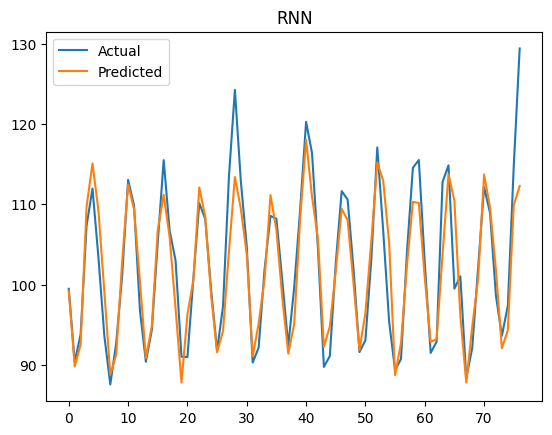

In [19]:
#RNN
rnn = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(seq_len, 1)),
    Dense(1)
])

rnn.compile(optimizer='adam', loss='mse')
rnn.fit(X_train, y_train, epochs=10, batch_size=16, verbose=0)

evaluate(rnn, "RNN")

3/3 [==============================] - 1s 9ms/step
LSTM RMSE: 10.574681171355728


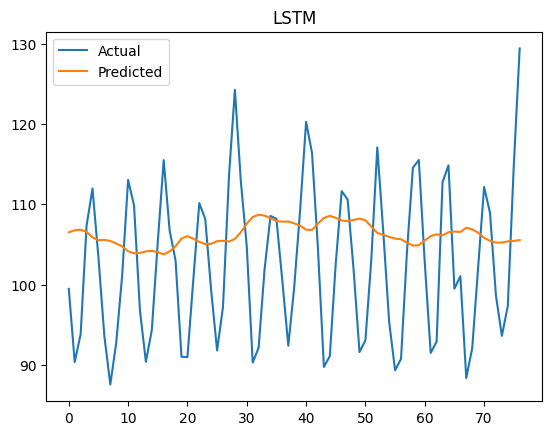

In [20]:
#LSTM
lstm = Sequential([
    LSTM(64, activation='tanh', input_shape=(seq_len, 1)),
    Dense(1)
])

lstm.compile(optimizer='adam', loss='mse')
lstm.fit(X_train, y_train, epochs=10, batch_size=16, verbose=0)

evaluate(lstm, "LSTM")

3/3 [==============================] - 2s 10ms/step
GRU RMSE: 9.489226257501727


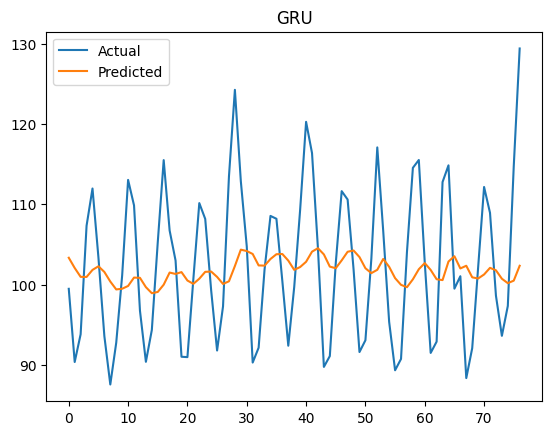

In [21]:
#GRU
gru = Sequential([
    GRU(64, activation='tanh', input_shape=(seq_len, 1)),
    Dense(1)
])

gru.compile(optimizer='adam', loss='mse')
gru.fit(X_train, y_train, epochs=10, batch_size=16, verbose=0)

evaluate(gru, "GRU")


3/3 [==============================] - 0s 9ms/step
Transformer RMSE: 18.79220329790687


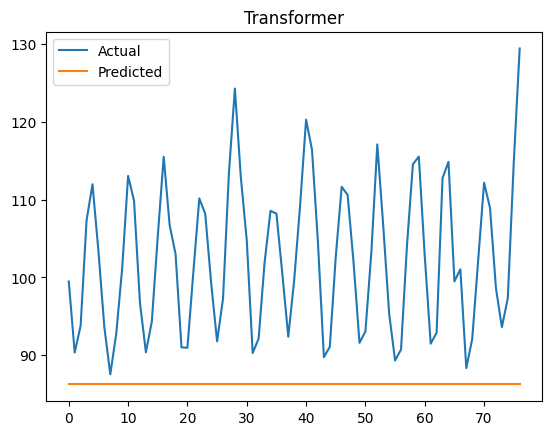

In [24]:
#ViT for time series
inputs = Input(shape=(seq_len, 1))

x = LayerNormalization()(inputs)
x = MultiHeadAttention(num_heads=2, key_dim=16)(x, x)
x = Dropout(0.1)(x)

x = GlobalAveragePooling1D()(x)
outputs = Dense(1)(x)

transformer = tf.keras.Model(inputs, outputs)

transformer.compile(optimizer='adam', loss='mse')
transformer.fit(X_train, y_train, epochs=10, batch_size=16, verbose=0)

evaluate(transformer, "Transformer")